In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [2]:
spy  = pd.read_csv('data/TSLA_features.csv',  parse_dates=['date'], index_col='date').sort_index()

In [3]:
spy.head()

,adj_close,close,high,low,open,volume,daily_return,weekly_return,ma_7,ma_21,...,lag_return_5,month,quarter,season_num,season,is_earnings_week,vix,is_major_event,target_direction,target_return
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,-0.013938,-0.013273,14.863905,14.497746,...,0.005838,1,1,0,Winter,0,17.790001,0,0,-0.057681
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,-0.042041,-0.077825,14.760286,14.436762,...,0.025016,1,1,0,Winter,0,19.920000,0,1,-0.037508
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,0.005664,-0.063932,14.655714,14.382794,...,-0.009262,1,1,0,Winter,0,21.120001,0,0,-0.033273
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562,-0.050758,14.495047,14.342286,...,-0.015418,1,1,0,Winter,0,19.309999,0,0,-0.086561
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564,-0.053010,14.351333,14.330413,...,0.000810,1,1,0,Winter,0,17.010000,0,0,-0.089023


In [4]:
FEATURES = [
    'daily_return', 'weekly_return', 'ma_cross', 'dist_from_ma21', 'daily_range',
    'rsi_14', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20',
    'volume_change', 'volume_ratio',
    'lag_return_1', 'lag_return_3', 'lag_return_5',
    'month', 'is_earnings_week',
    'vix', 'is_major_event'
]
TARGET_CLS = 'target_direction'

In [5]:
tsla_cls  = spy[FEATURES + [TARGET_CLS]].dropna().copy()

print(tsla_cls.shape)

(2515, 20)


In [6]:
def walk_forward_splits(df, train_window, test_window=42, embargo=5):
    splits = []
    n = len(df)
    start = 0

    while start + train_window + embargo + test_window <= n:
        train_start = start
        train_end   = start + train_window
        test_start  = train_end + embargo
        test_end    = test_start + test_window

        train_idx = list(range(train_start, train_end))
        test_idx  = list(range(test_start, test_end))

        splits.append((train_idx, test_idx))
        start += test_window

    return splits

In [7]:
tsla_folds = walk_forward_splits(tsla_cls, train_window = 59)
print("TSLA folds:", len(tsla_folds))

TSLA folds: 58


In [8]:
fold_scores = [] # metrics of each fold stored
tsla_actual, tsla_pred = [], [] # actual and predicted values
tsla_probs = [] # P(UP) for each test day across all folds

for train_idx, test_idx in tsla_folds:
    X_train = tsla_cls.iloc[train_idx][FEATURES]
    y_train = tsla_cls.iloc[train_idx][TARGET_CLS]
    X_test  = tsla_cls.iloc[test_idx][FEATURES]
    y_test  = tsla_cls.iloc[test_idx][TARGET_CLS]

    # standardization
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train) 
    X_test  = scaler.transform(X_test) 

   # train + predict
    svm = SVC(kernel='rbf', C=10, gamma=0.1,
              class_weight='balanced', probability=True, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    y_prob = svm.predict_proba(X_test)[:, 1]   # P(class = UP)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    

    # store fold metrics
    fold_scores.append({
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "specificity": specificity,
        "f1":        f1_score(y_test, y_pred, zero_division=0)
    })
    tsla_actual.extend(y_test)
    tsla_pred.extend(y_pred)
    tsla_probs.extend(y_prob)

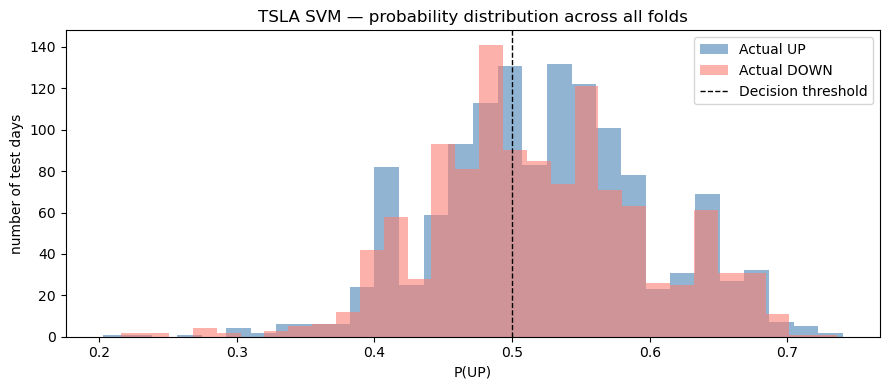

Prob range: 0.203 to 0.740
Mean P(UP) for actual UP days:   0.523
Mean P(UP) for actual DOWN days: 0.519


In [9]:
tsla_actual_arr = np.array(tsla_actual)
tsla_probs_arr  = np.array(tsla_probs)

# Distribution plot
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.hist(tsla_probs_arr[tsla_actual_arr == 1], bins=30, alpha=0.6, label='Actual UP',   color='steelblue')
ax.hist(tsla_probs_arr[tsla_actual_arr == 0], bins=30, alpha=0.6, label='Actual DOWN', color='salmon')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold')
ax.set_xlabel('P(UP)')
ax.set_ylabel('number of test days')
ax.set_title('TSLA SVM — probability distribution across all folds')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Prob range: {tsla_probs_arr.min():.3f} to {tsla_probs_arr.max():.3f}")
print(f"Mean P(UP) for actual UP days:   {tsla_probs_arr[tsla_actual_arr == 1].mean():.3f}")
print(f"Mean P(UP) for actual DOWN days: {tsla_probs_arr[tsla_actual_arr == 0].mean():.3f}")

In [10]:
tsla_results = pd.DataFrame(fold_scores)
tsla_results

,accuracy,precision,recall,specificity,f1
0,0.500000,0.500000,0.619048,0.380952,0.553191
1,0.380952,0.384615,0.217391,0.578947,0.277778
2,0.571429,0.550000,1.000000,0.100000,0.709677
3,0.571429,0.538462,0.700000,0.454545,0.608696
4,0.452381,0.250000,0.105263,0.739130,0.148148
5,0.333333,1.000000,0.034483,1.000000,0.066667
6,0.428571,0.400000,0.526316,0.347826,0.454545
7,0.571429,0.542857,0.904762,0.238095,0.678571
8,0.452381,0.452381,1.000000,0.000000,0.622951
9,0.500000,0.428571,0.705882,0.360000,0.533333


In [11]:
tsla_results.describe()

,accuracy,precision,recall,specificity,f1
count,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.489737,0.494526,0.589941,0.405186,0.488064
std,0.078286,0.195379,0.329182,0.326030,0.210412
min,0.333333,0.000000,0.000000,0.000000,0.000000
25%,0.428571,0.429762,0.370238,0.119485,0.402941
50%,0.476190,0.500000,0.622024,0.353913,0.541176
75%,0.547619,0.575549,0.910973,0.656250,0.609801
max,0.666667,1.000000,1.000000,1.000000,0.787879


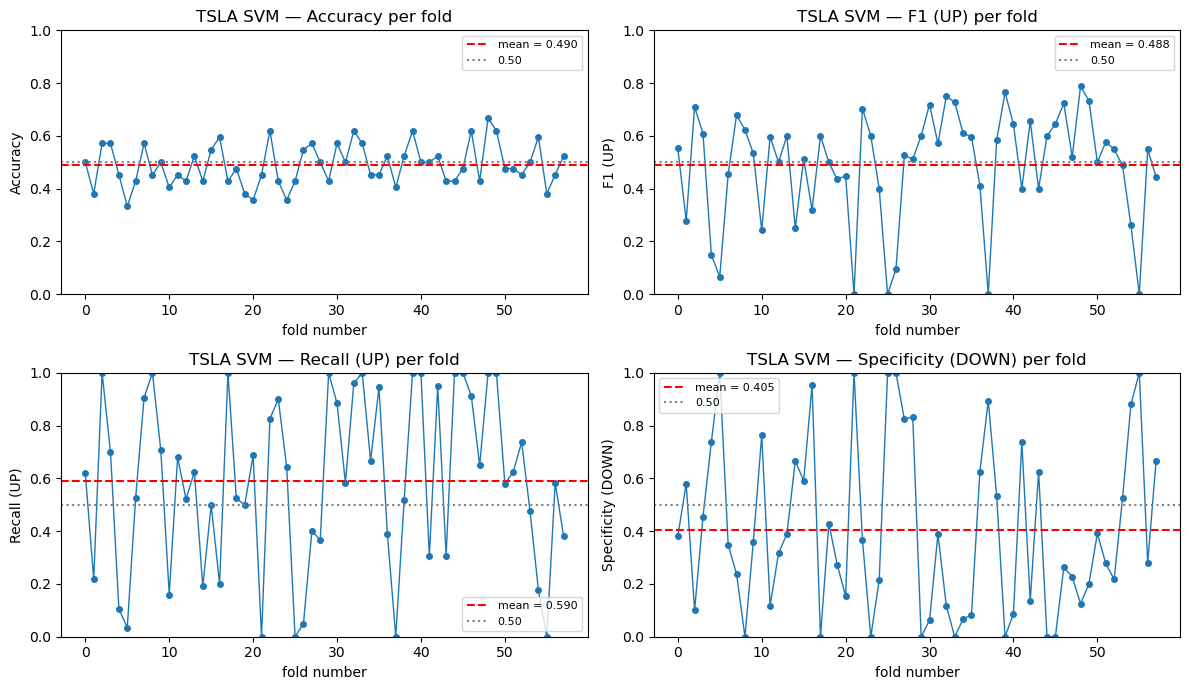

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

metrics = [
    ('accuracy',    'Accuracy',    axes[0, 0]),
    ('f1',          'F1 (UP)',     axes[0, 1]),
    ('recall',      'Recall (UP)', axes[1, 0]),
    ('specificity', 'Specificity (DOWN)', axes[1, 1]),
]

for col, label, ax in metrics:
    ax.plot(tsla_results.index, tsla_results[col], marker='o', linewidth=1, markersize=4)
    ax.axhline(tsla_results[col].mean(), color='red', linestyle='--',
               label=f'mean = {tsla_results[col].mean():.3f}')
    ax.axhline(0.5, color='gray', linestyle=':', label='0.50')
    ax.set_xlabel('fold number')
    ax.set_ylabel(label)
    ax.set_title(f'TSLA SVM — {label} per fold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
print(classification_report(tsla_actual, tsla_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.46      0.39      0.42      1170
           1       0.51      0.58      0.54      1266

    accuracy                           0.49      2436
   macro avg       0.49      0.49      0.48      2436
weighted avg       0.49      0.49      0.49      2436



In [14]:
C_values     = [0.1, 1, 10, 100, 1000]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

print(f'Grid: {len(C_values)} × {len(gamma_values)} = {len(C_values) * len(gamma_values)} combinations')
print(f'Folds per combo: {len(tsla_folds)}')
print(f'Total SVM fits: {len(C_values) * len(gamma_values) * len(tsla_folds)}')

Grid: 5 × 5 = 25 combinations
Folds per combo: 58
Total SVM fits: 1450


In [15]:
grid_results = []

for C in C_values:
    for gamma in gamma_values:
        fold_f1s   = []
        fold_accs  = []
        fold_precs = []
        fold_recs  = []
        fold_specs = []   

        for train_idx, test_idx in tsla_folds:
            X_train = tsla_cls.iloc[train_idx][FEATURES]
            y_train = tsla_cls.iloc[train_idx][TARGET_CLS]
            X_test  = tsla_cls.iloc[test_idx][FEATURES]
            y_test  = tsla_cls.iloc[test_idx][TARGET_CLS]

            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

            svm = SVC(kernel='rbf', C=C, gamma=gamma,
                      class_weight='balanced', random_state=42)
            svm.fit(X_train, y_train)
            y_pred = svm.predict(X_test)

            fold_f1s.append(f1_score(y_test, y_pred, zero_division=0))
            fold_accs.append(accuracy_score(y_test, y_pred))
            fold_precs.append(precision_score(y_test, y_pred, zero_division=0))
            fold_recs.append(recall_score(y_test, y_pred, zero_division=0))

            # Specificity = TN / (TN + FP) = recall of the DOWN class
            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            fold_specs.append(spec)

        grid_results.append({
            'C': C,
            'gamma': gamma,
            'f1':          np.mean(fold_f1s),
            'accuracy':    np.mean(fold_accs),
            'precision':   np.mean(fold_precs),
            'recall':      np.mean(fold_recs),
            'specificity': np.mean(fold_specs),
        })
        print(f'  C={C:>6}  gamma={gamma:<6}  '
              f'F1={np.mean(fold_f1s):.3f}  '
              f'acc={np.mean(fold_accs):.3f}  '
              f'prec={np.mean(fold_precs):.3f}  '
              f'rec={np.mean(fold_recs):.3f}  '
              f'spec={np.mean(fold_specs):.3f}')

grid_df = pd.DataFrame(grid_results)

  C=   0.1  gamma=0.001   F1=0.414  acc=0.514  prec=0.319  rec=0.603  spec=0.397
  C=   0.1  gamma=0.01    F1=0.414  acc=0.514  prec=0.319  rec=0.603  spec=0.397
  C=   0.1  gamma=0.1     F1=0.414  acc=0.514  prec=0.319  rec=0.603  spec=0.397
  C=   0.1  gamma=1       F1=0.414  acc=0.514  prec=0.319  rec=0.603  spec=0.397
  C=   0.1  gamma=10      F1=0.414  acc=0.514  prec=0.319  rec=0.603  spec=0.397
  C=     1  gamma=0.001   F1=0.376  acc=0.504  prec=0.288  rec=0.551  spec=0.450
  C=     1  gamma=0.01    F1=0.403  acc=0.489  prec=0.509  rec=0.423  spec=0.581
  C=     1  gamma=0.1     F1=0.446  acc=0.481  prec=0.491  rec=0.527  spec=0.466
  C=     1  gamma=1       F1=0.410  acc=0.503  prec=0.313  rec=0.603  spec=0.398
  C=     1  gamma=10      F1=0.410  acc=0.503  prec=0.313  rec=0.603  spec=0.397
  C=    10  gamma=0.001   F1=0.422  acc=0.489  prec=0.492  rec=0.453  spec=0.547
  C=    10  gamma=0.01    F1=0.440  acc=0.490  prec=0.504  rec=0.506  spec=0.500
  C=    10  gamma=0.1     F1

In [16]:
print('Top 5 by F1:')
print(grid_df.sort_values('f1', ascending=False).head().to_string(index=False))

print('Top 5 by ACCURACY:')
print(grid_df.sort_values('accuracy', ascending=False).head().to_string(index=False))

print('Top 5 by Precision:')
print(grid_df.sort_values('precision', ascending=False).head().to_string(index=False))

print('Top 5 by Recall:')
print(grid_df.sort_values('recall', ascending=False).head().to_string(index=False))

print('Top 5 by Specificity :')
print(grid_df.sort_values('specificity', ascending=False).head().to_string(index=False))

print('\nCurrent baseline (C=10, gamma=0.1):')
print(grid_df[(grid_df['C'] == 10) & (grid_df['gamma'] == 0.1)].to_string(index=False))

Top 5 by F1:
     C  gamma       f1  accuracy  precision   recall  specificity
  10.0   0.10 0.488064  0.489737   0.494526 0.589941     0.405186
1000.0   0.10 0.486223  0.490148   0.494047 0.586480     0.407644
 100.0   0.10 0.486223  0.490148   0.494047 0.586480     0.407644
1000.0   0.01 0.459118  0.488506   0.497699 0.526793     0.461282
 100.0   0.01 0.455985  0.481527   0.502527 0.525163     0.462548
Top 5 by ACCURACY:
  C  gamma       f1  accuracy  precision   recall  specificity
0.1  0.001 0.414441  0.513957   0.318555 0.603448     0.396552
0.1  0.010 0.414441  0.513957   0.318555 0.603448     0.396552
0.1  0.100 0.414441  0.513957   0.318555 0.603448     0.396552
0.1  1.000 0.414441  0.513957   0.318555 0.603448     0.396552
0.1 10.000 0.414441  0.513957   0.318555 0.603448     0.396552
Top 5 by Precision:
     C  gamma       f1  accuracy  precision   recall  specificity
   1.0  0.010 0.403113  0.489327   0.508693 0.422549     0.581422
  10.0  0.010 0.440145  0.489737   0.50378